## **Descriptive and Probabilistic Analysis of Air Quality in Yogyakarta, Indonesia (2021)**
- **Group Number:** 12
- **Name:**
1. Muhammad Akbar Rizky Hidayat - 5027261032
2. Dhafin Abhinaya Setyawan - 5027261083
3. Jenifer Tri Fena Andhika - 5027261123
- **Topic:** Smart City

### **Background**
Air quality is one of the key indicators for assessing a city’s sustainability, especially amid the rapid growth of transportation and industrial activities across various regions of Indonesia. The “Air Quality in Yogyakarta, Indonesia (2021)” dataset contains air pollution measurement data for Yogyakarta throughout 2021. Our group chose this dataset because Yogyakarta is one of Indonesia’s major cities with high population and vehicle mobility levels, making the data relevant for providing a general picture of urban air quality. Through descriptive statistics analysis of this data, we aim to illustrate the patterns and levels of air quality in Yogyakarta throughout the year, while connecting them to the Sustainable Development Goals (SDGs), specifically SDG 3 (Good Health and Well-being), as air quality directly impacts public respiratory health, and SDG 11 (Sustainable Cities and Communities) because air quality monitoring is a crucial part of efforts to create safe, inclusive, and sustainable cities. Thus, the results of this analysis are expected to serve as a simple example of how a city’s air quality data can be used to raise awareness and data-driven decision-making toward more sustainable urban development.

### **Questions:**
1. What are the mode, median, mean, range, and variance of PM2.5 and PM10 concentrations in Yogyakarta for each month throughout the year?
2. Which hours of the day show the highest and lowest average pollutant concentrations?
3. What proportion of hours or days fall into each category (Good, Moderate, Unhealthy, Very Unhealthy, Dangerous)?

### **Data Description and Dictionary**
- Source of data: The data comes from the Yogyakarta Environmental Agency (Dinas Lingkungan Hidup Yogyakarta), which was processed and uploaded to Kaggle by Adhang MM at this link: https://www.kaggle.com/datasets/adhang/air-quality-in-yogyakarta-indonesia-2021
- License: Data files © Original Authors
- The data was collected by the Yogyakarta Environmental Agency in April 2021. Measurements were taken hourly. The original pollution values were converted into the Pollutant Standards Index (PSI/ISPU).
- The data has 11 columns for each month.
- January, March, May, July, August, October, and December consist of 744 rows.
- February consists of 674 rows.
- April, June, September, and November consist of 720 rows.

| Column | Definition | Variable Type | Scale | Units | Example |
| --- | --- | --- | --- | --- | --- |
| Date | The date measurement was taken | Qualitative | Interval | - | 4/1/2021 |
| Time | The time measurement was taken (hourly) | Qualitative | Interval | - | 00:00:00 | 
| PM2.5 | Particulate Matter 2.5 measurement (Index) | Quantitative Continuous | Ratio | PSI | 45 |
| PM10 | Particulate Matter 10 measurement (Index) | Quantitative Continuous | Ratio | PSI | 19 |
| SO2 | Sulfur Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| CO | Carbon Monoxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 15 |
| O3 | Ozone measurement (Index) | Quantitative Continuous | Ratio | PSI | 8 |
| NO2 | Nitrogen Dioxide measurement (Index) | Quantitative Continuous | Ratio | PSI | 3 |
| Max | Highest pollution measurement value at that hour | Quantitative Continuous | Ratio | PSI | 45 |
| Critical Component | Gas component contributing to the highest pollution | Qualitative | Nominal | - | PM2.5 |
| Category | Air quality category based on the Max value | Qualitative | Ordinal | - | Good |

### **Yogyakarta's Air Quality Dataset in January 2021**

In [1]:
import pandas as pd

df = pd.read_csv("01-jogja-jan-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,1/1/2021,00:00:00,13,40,0,25,0,0,40,PM2.5,Good
2,1/1/2021,01:00:00,12,38,0,24,0,0,38,PM2.5,Good
3,1/1/2021,02:00:00,11,35,0,23,0,0,35,PM2.5,Good
4,1/1/2021,03:00:00,10,32,0,22,0,0,32,PM2.5,Good
5,1/1/2021,04:00:00,9,29,0,21,0,0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,1/31/2021,19:00:00,25,66,19,25,40,6,66,PM2.5,Moderate
741,1/31/2021,20:00:00,24,65,19,24,39,5,65,PM2.5,Moderate
742,1/31/2021,21:00:00,23,64,19,24,38,5,64,PM2.5,Moderate
743,1/31/2021,22:00:00,23,63,19,24,38,5,63,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 01-jogja-jan-2021.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                744 non-null    object
 1   Time                744 non-null    object
 2   PM10                744 non-null    int64 
 3   PM2.5               744 non-null    int64 
 4   SO2                 744 non-null    int64 
 5   CO                  744 non-null    int64 
 6   O3                  744 non-null    int64 
 7   NO2                 744 non-null    int64 
 8   Max                 744 non-null    int64 
 9   Critical Component  744 non-null    object
 10  Category            744 non-null    object
dtypes: int64(7), object(4)
memory usage: 64.1+ KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 01-jogja-jan-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,16.063172,46.782258,14.005376,24.534946,22.290323,2.469086,48.432796
std,8.358234,18.616724,10.531244,3.355775,17.578254,2.179462,16.666334
min,2.000000,12.000000,0.000000,17.000000,0.000000,0.000000,19.000000
25%,8.000000,30.000000,1.000000,22.000000,0.000000,0.000000,34.000000
50%,16.000000,52.000000,20.000000,25.000000,26.000000,3.000000,52.000000
75%,21.000000,60.000000,23.000000,27.000000,38.000000,4.000000,60.000000
max,35.000000,80.000000,28.000000,33.000000,55.000000,7.000000,80.000000


##### <span style="color:blue">**1. PM2.5**</span>

In [4]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 46.78225806451613
Median: 52.0
Mode: 55
Variance: 346.58240350801026
Standard Deviation: 18.616723758707124
Q1 (25%): 30.0
Q3 (75%): 60.0


##### <span style="color:blue">**2. PM10**</span>

In [5]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM10"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 16.063172043010752
Median: 16.0
Mode: 6
Variance: 69.8600685248701
Standard Deviation: 8.358233576831298
Q1 (25%): 8.0
Q3 (75%): 21.0


##### <span style="color:blue">**3. CO**</span>

In [6]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["CO"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 24.53494623655914
Median: 25.0
Mode: 26
Variance: 11.261226645827003
Standard Deviation: 3.3557751184826143
Q1 (25%): 22.0
Q3 (75%): 27.0


##### <span style="color:blue">**4. O3**</span>

In [7]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["O3"]
print("Mean:", kolom.mean())
print("Median:", kolom.median())
print("Mode:", kolom.mode()[0])
print("Variance:", kolom.var())
print("Standard Deviation:", kolom.std())
print("Q1 (25%):", kolom.quantile(0.25))
print("Q3 (75%):", kolom.quantile(0.75))

Data source: 01-jogja-jan-2021.csv
Mean: 22.29032258064516
Median: 26.0
Mode: 0
Variance: 308.9950071636348
Standard Deviation: 17.57825381440474
Q1 (25%): 0.0
Q3 (75%): 38.0


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [8]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 01-jogja-jan-2021.csv


Critical Component
PM2.5    82.930108
O3       11.424731
CO        4.704301
SO2       0.940860
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [9]:
filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 01-jogja-jan-2021.csv


Category
Moderate    53.897849
Good        46.102151
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 01-jogja-jan-2021.csv


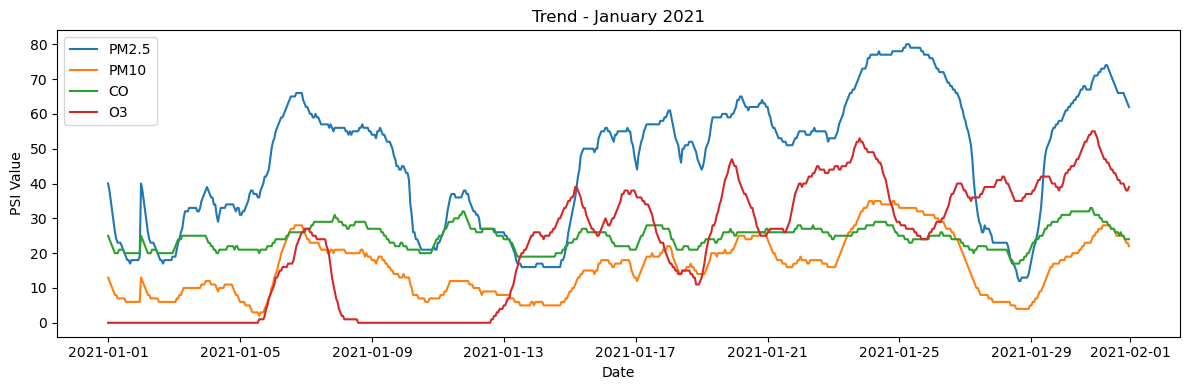

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the January data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - January 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In January 2021, PM2.5 stayed the highest and moved up and down the most (between about 20–80), O3 was almost zero for the first two weeks but then spiked a lot in the second half, while PM10 and CO stayed low and pretty steady the whole month.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 01-jogja-jan-2021.csv


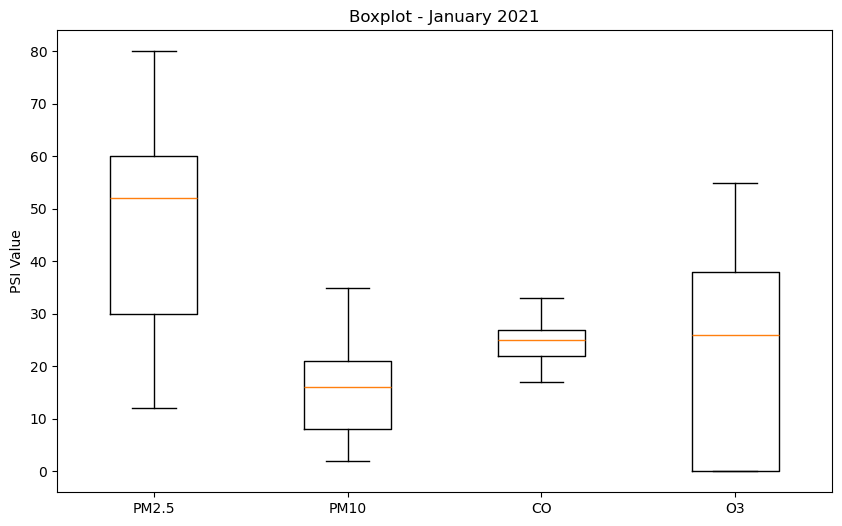

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - January 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

None of the pollutants in January 2021 show outliers based on the 1.5×IQR rule, but PM2.5 has by far the widest spread (12–80) and the highest median (~52), while CO stays the most tightly packed, meaning PM2.5 levels varied a lot more day-to-day than the others.

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 01-jogja-jan-2021.csv


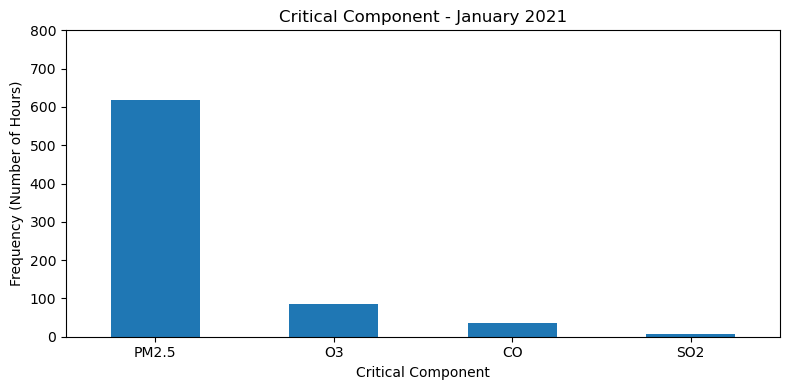

Critical Component
PM2.5    617
O3        85
CO        35
SO2        7
Name: count, dtype: int64

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - January 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()

During January 2021, PM2.5 was the most frequent driver of poor air quality (617 hours), far exceeding O3, CO, and SO2, which each recorded under 100 hours.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "01-jogja-jan-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - January 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

In January 2021, air quality was fairly evenly split between Moderate (401 hours) and Good (343 hours), with no single category clearly dominating the month.

### **Yogyakarta's Air Quality Dataset in February 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("02-jogja-feb-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(672)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 02-jogja-feb-2021.csv


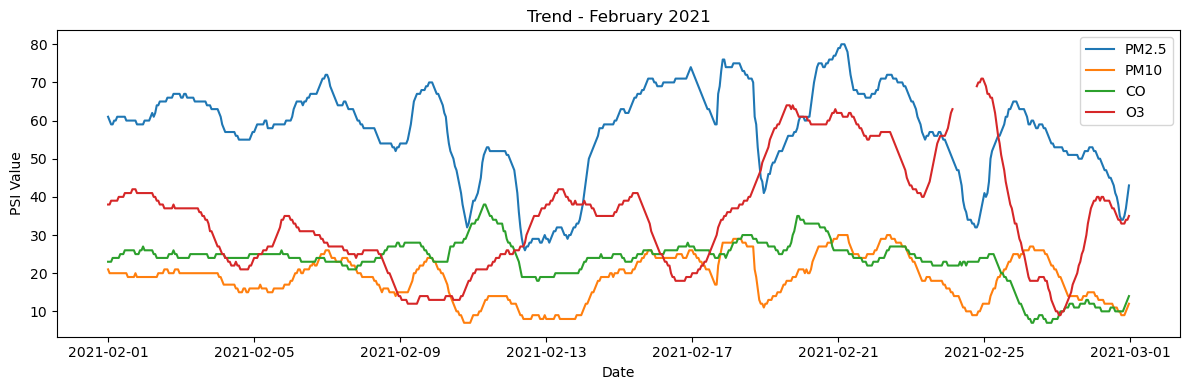

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the February data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - February 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In February 2021, PM2.5 stayed the highest most of the month (mostly 40–80), O3 also went up and down a lot and even crossed PM2.5 a few times, while PM10 and CO stayed lower and calmer overall.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 02-jogja-feb-2021.csv


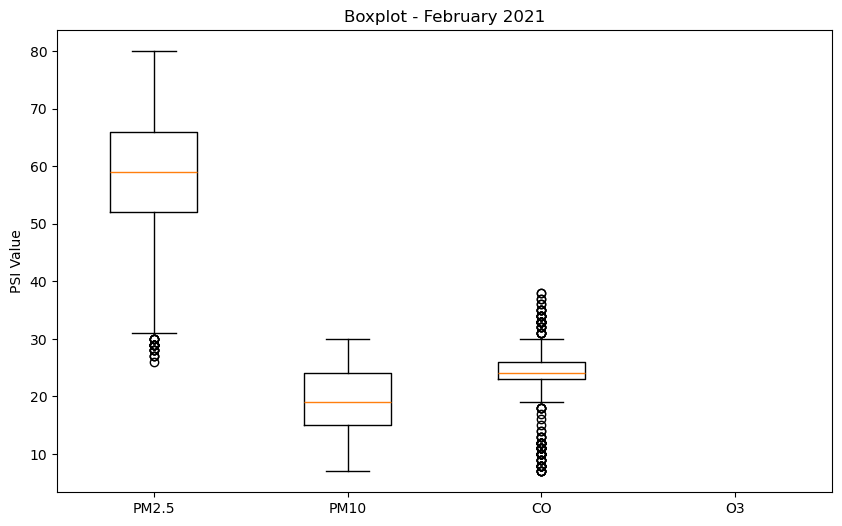

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - February 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [ ]:
print(df[["O3"]].describe())
print(df["O3"].isna().sum())

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 02-jogja-feb-2021.csv


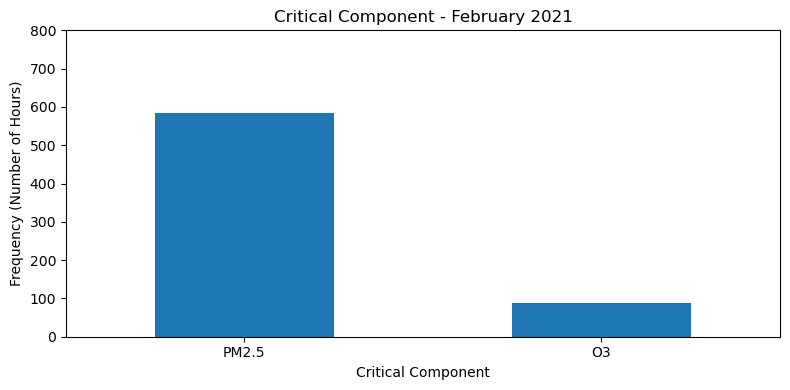

Critical Component
PM2.5    585
O3        87
Name: count, dtype: int64

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - February 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

In February 2021, PM2.5 was again the main driver of poor air quality (585 hours), far ahead of O3, CO, and SO2 which each stayed under 100 hours — the same pattern as January

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - February 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in March 2021**

In [17]:
import pandas as pd

df = pd.read_csv("03-jogja-mar-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,3/1/2021,00:00:00,13,48,19,15,35,6,48,PM2.5,Good
2,3/1/2021,01:00:00,14,51,19,16,36,6,51,PM2.5,Moderate
3,3/1/2021,02:00:00,15,52,20,17,37,6,52,PM2.5,Moderate
4,3/1/2021,03:00:00,16,54,20,17,37,6,54,PM2.5,Moderate
5,3/1/2021,04:00:00,17,55,21,18,38,6,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,3/31/2021,19:00:00,21,50,22,17,8,3,50,PM2.5,Good
741,3/31/2021,20:00:00,21,50,21,16,8,3,50,PM2.5,Good
742,3/31/2021,21:00:00,20,49,21,16,8,3,49,PM2.5,Good
743,3/31/2021,22:00:00,20,48,21,16,8,3,48,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 03-jogja-mar-2021.csv


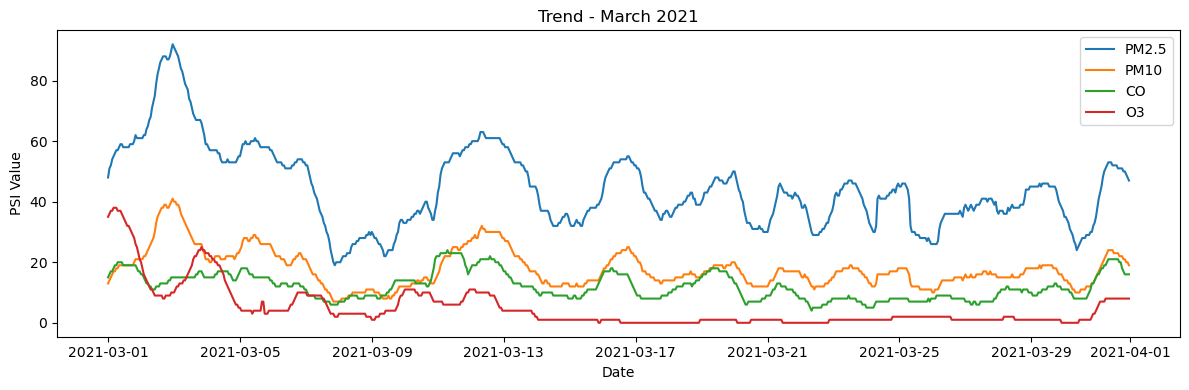

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the March data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - March 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In March 2021, PM2.5 stayed the highest all month with several ups and downs (roughly 20–85), while PM10 and CO stayed low and close together most of the time, and O3 dropped to near zero in the second half of the month.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 03-jogja-mar-2021.csv


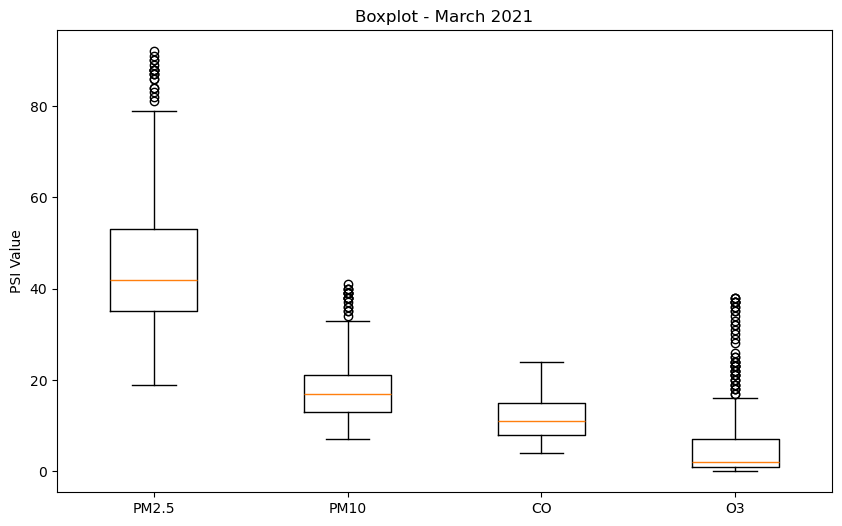

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - March 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In March 2021, PM2.5, PM10, and O3 all had high outliers (20, 20, and 51 points), with O3 having the most even though its median was low (2.0). CO had no outliers at all, and PM2.5 still had the highest median overall (42.0).

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 03-jogja-mar-2021.csv


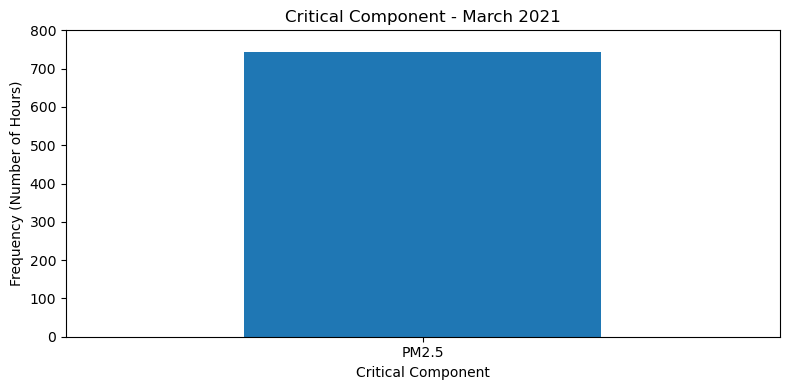

Critical Component
PM2.5    744
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")


plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - March 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  

In March 2021, PM2.5 was the critical component for all 744 hours of the month — no other pollutant (O3, CO, PM10, SO2) was ever the main driver of poor air quality

### **Yogyakarta's Air Quality Dataset in April 2021**

In [23]:
import pandas as pd

df = pd.read_csv("04-jogja-apr-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM2.5,PM10,SO2,CO,O3,NO2,Max,Critical Component,Category
1,4/1/2021,00:00:00,45,19,21,15,8.0,3,21,PM2.5,Good
2,4/1/2021,01:00:00,44,18,20,14,8.0,3,20,PM2.5,Good
3,4/1/2021,02:00:00,43,17,20,14,7.0,3,20,PM2.5,Good
4,4/1/2021,03:00:00,40,17,20,13,7.0,3,20,PM2.5,Good
5,4/1/2021,04:00:00,38,16,19,12,7.0,3,19,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,4/30/2021,19:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
717,4/30/2021,20:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
718,4/30/2021,21:00:00,54,23,17,13,NaN,4,23,PM2.5,Good
719,4/30/2021,22:00:00,54,23,17,13,NaN,4,23,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 04-jogja-apr-2021.csv


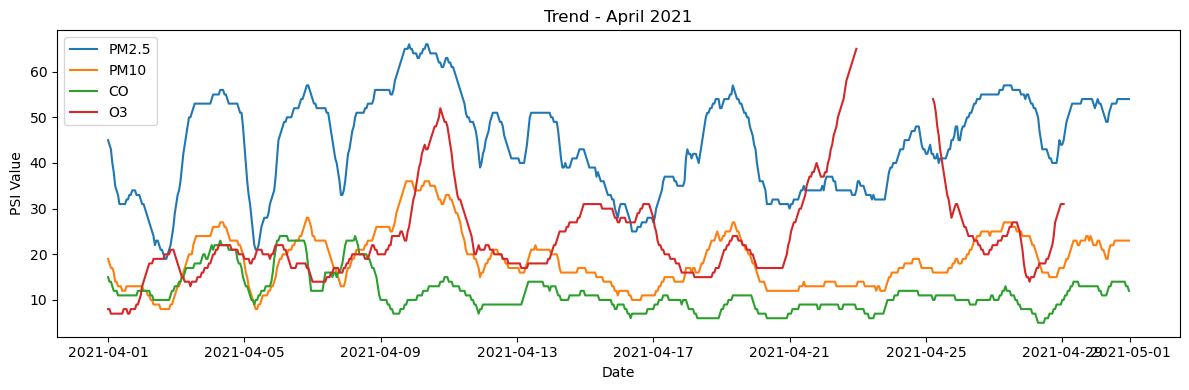

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the April data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - April 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In April 2021, PM2.5 was still the highest most of the time (roughly 15–65), O3 spiked sharply a few times (like around April 9 and April 23) but stayed low in between, while PM10 and CO stayed low and fairly steady all month.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 04-jogja-apr-2021.csv


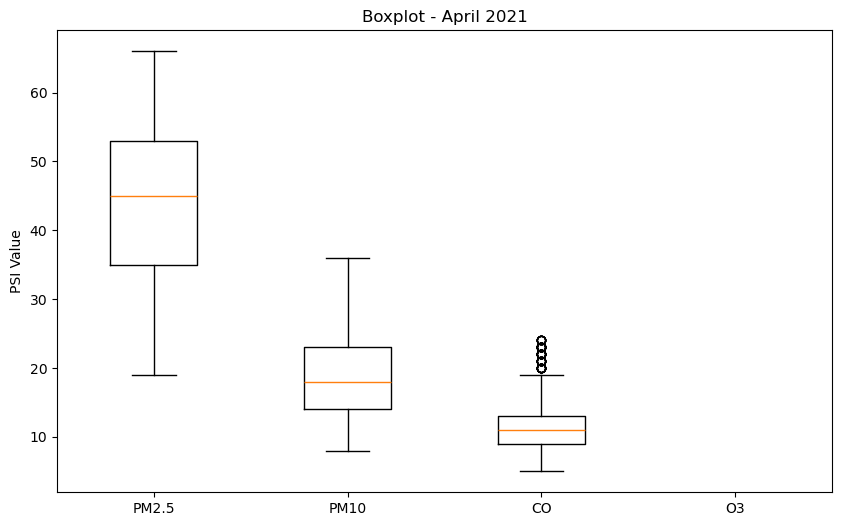

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - April 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 04-jogja-apr-2021.csv


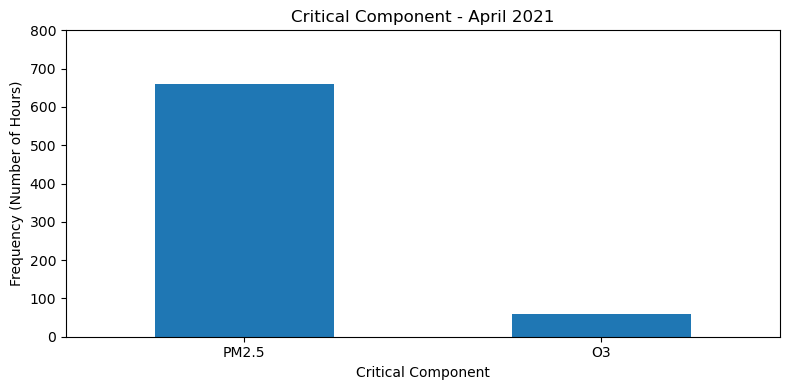

Critical Component
PM2.5    660
O3        60
Name: count, dtype: int64

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - April 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

In April 2021, PM2.5 was the critical component for the vast majority of the month (660 hours), while O3 only accounted for 60 hours — no other pollutant was ever the main driver.

In [ ]:
import pandas as pd

df = pd.read_csv("05-jogja-may-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 05-jogja-may-2021.csv


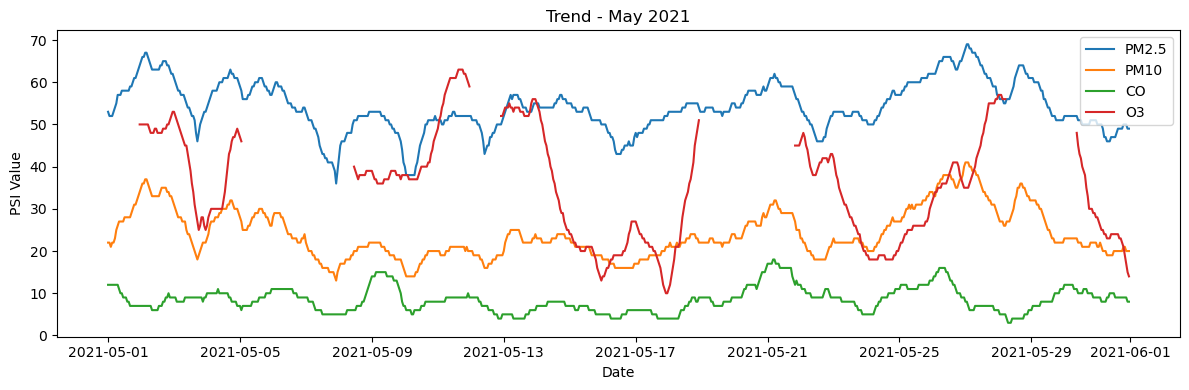

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the May data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - May 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In May 2021, PM2.5 stayed the highest most of the month (roughly 40–70), O3 swung wildly up and down with several sharp drops and spikes, and PM10 and CO stayed low and steady throughout.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 05-jogja-may-2021.csv


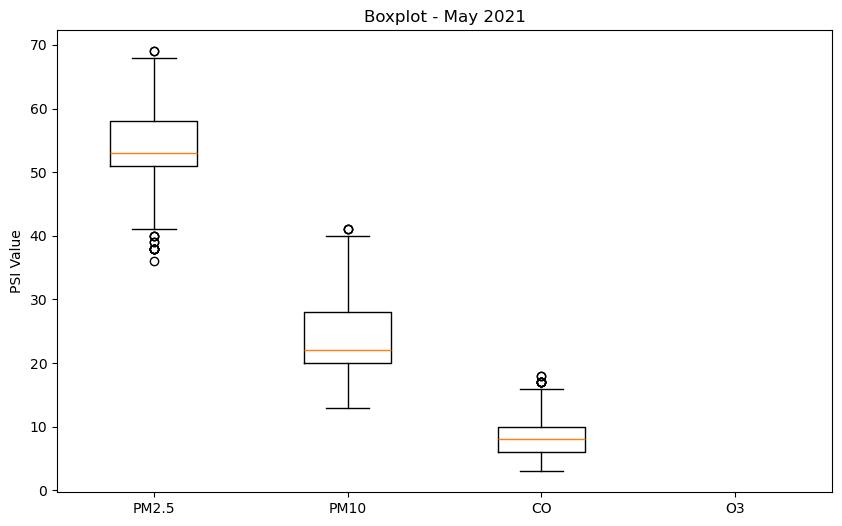

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - May 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 05-jogja-may-2021.csv


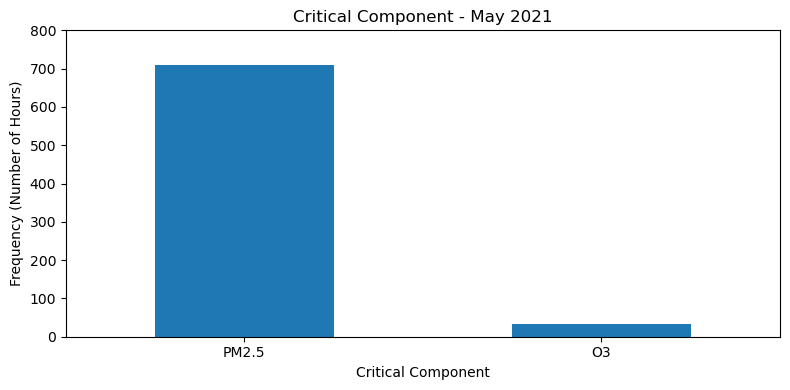

Critical Component
PM2.5    710
O3        34
Name: count, dtype: int64

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - May 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

In May 2021, PM2.5 was the critical component almost all month (710 hours), while O3 only briefly took over for 34 hours — no other pollutant was ever the main driver.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "05-jogja-may-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df_jan["Category"].value_counts().plot(kind="bar")
plt.title("Category - May 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in June 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("06-jogja-jun-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 06-jogja-jun-2021.csv


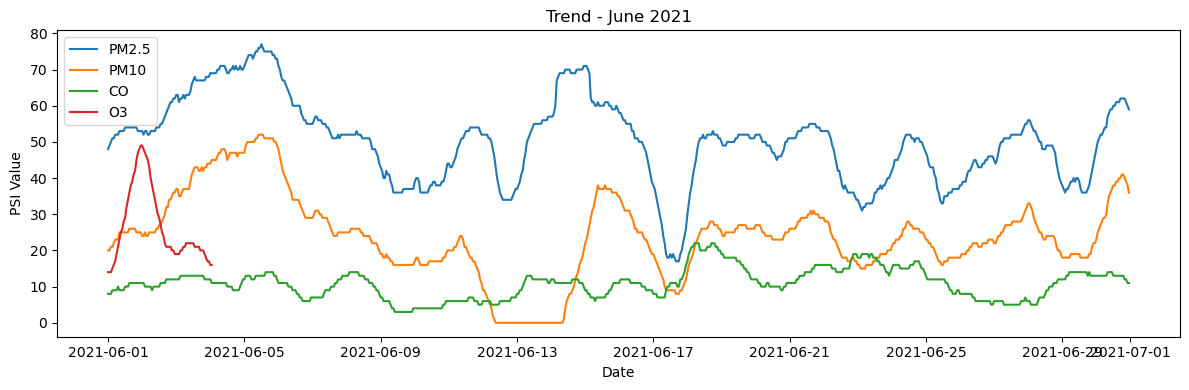

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the June data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - June 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

In June 2021, PM2.5 was still the highest most of the month (17–77), O3 only had data for the first week and then disappeared (missing for the rest of the month), while PM10 and CO stayed lower and moved together throughout.

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 06-jogja-jun-2021.csv


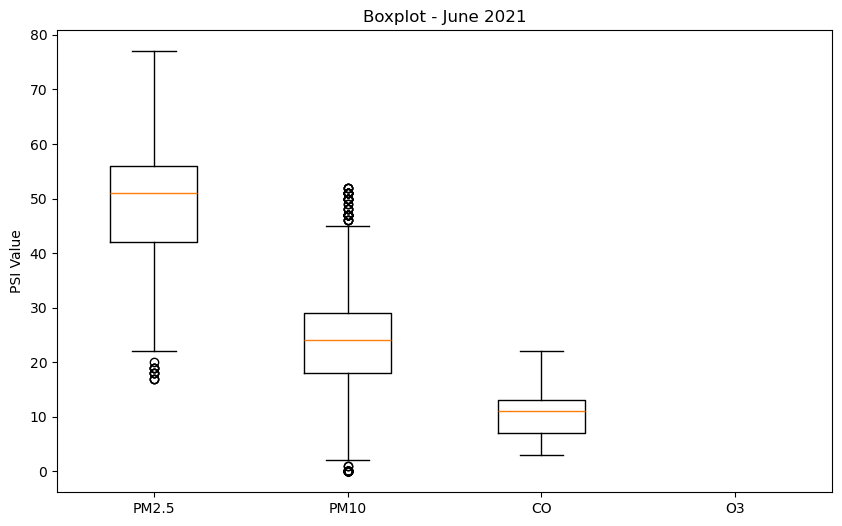

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col] for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - June 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 06-jogja-jun-2021.csv


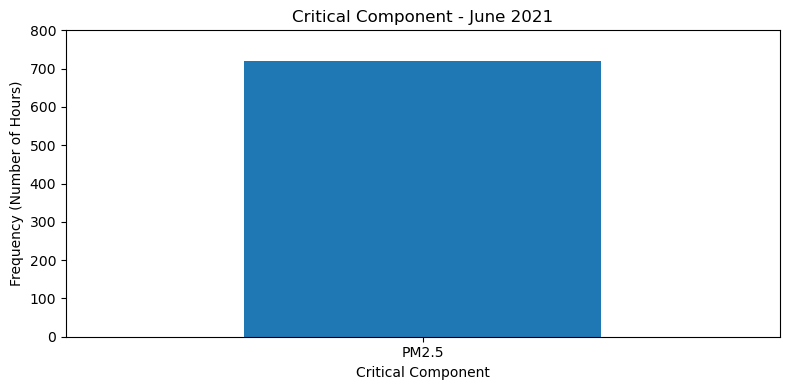

Critical Component
PM2.5    720
Name: count, dtype: int64

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - June 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()

In June 2021, PM2.5 was the critical component for all 720 hours of the month — no other pollutant was ever the main driver, the same pattern as March

### **Yogyakarta's Air Quality Dataset in July 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("07-jogja-jul-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
import pandas as pd

In [ ]:
filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - July 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - July 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df[numeric_cols].isna().sum())
print(df[numeric_cols].describe())

##### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - July 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "07-jogja-jul-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - July 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in August 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("08-jogja-aug-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - August 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
# ===== Agustus 2021 =====
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - August 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - August 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "08-jogja-aug-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - August 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in September 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("09-jogja-sep-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the July data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - September 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - September 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - September 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "09-jogja-sep-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - September 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in October 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("10-jogja-oct-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - October 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - October 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - October 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "10-jogja-oct-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - October 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in November 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("11-jogja-nov-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - November 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - November 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

##### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - November 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - November 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Yogyakarta's Air Quality Dataset in December 2021**

In [ ]:
import pandas as pd

df = pd.read_csv("12-jogja-dec-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

#### <span style="color:blue">**Data Quality Check**</span>

In [ ]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [ ]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [ ]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

##### <span style="color:blue">**2. Category**</span>

In [ ]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

#### <span style="color:blue">**Data Visualization**</span>

#### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - December 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

#### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - December 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

#### <span style="color:blue">**3. Bar Chart**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - December 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - December 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

### **Conclusion**
jjj